In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set seed 
np.random.seed(42)

In [47]:
sns.set_theme(style="whitegrid")
sns.set_context("paper", font_scale=1.2)
sns.set_palette("Spectral", n_colors=12)

sns.color_palette("Spectral", n_colors=12)


[(0.7803152633602461, 0.182160707420223, 0.2968089196462899),
 (0.8996539792387543, 0.340715109573241, 0.2848904267589389),
 (0.9679354094579008, 0.5074202229911572, 0.2996539792387543),
 (0.9923875432525952, 0.6938869665513263, 0.3900807381776239),
 (0.9954632833525567, 0.8476739715494039, 0.519261822376009),
 (0.9985390234525182, 0.9547097270280661, 0.6730488273740869),
 (0.9634755863129566, 0.9853902345251826, 0.6920415224913495),
 (0.8656670511341794, 0.9460207612456749, 0.6034602076124567),
 (0.6841983852364477, 0.8722029988465976, 0.6403690888119954),
 (0.48489042675893923, 0.7940023068050751, 0.6458285274894272),
 (0.30403690888119955, 0.6537485582468281, 0.6913494809688582),
 (0.24006151480199922, 0.47635524798154555, 0.7141868512110727)]

# 1. Handling the data

In [48]:
df = pd.read_csv('forPython.csv', sep = ';', decimal = ',')
df.head()

,Sample,Time,cDC1,Macrophages,cDC2,pDCs,MDP,Monocytes,HSC,T cells,DCPs,B cells,"NK cells, Eosinophils, granulocytes, neutrophils",Others
0,US,Before Thawing,0.0000,0.0000,0.00000,0.0000,0.00000,0.00000,0.00000,0.9940,0.000,0.00000,0.0000,0.00600
1,Pre-sort,Before Thawing,0.0099,0.0546,0.02208,0.0195,0.00022,0.08410,0.00066,0.0906,0.210,0.07230,0.1570,0.27904
2,Sorted,Before Thawing,0.0024,0.0000,0.00000,0.0001,0.00000,0.00025,0.00470,0.6650,0.303,0.00055,0.0016,0.02240
3,After thawing,Day 0,0.0020,0.0340,0.01640,0.0008,0.00280,0.06920,0.00000,0.0512,0.615,0.00120,0.0100,0.19740
4,US,Day 0,0.0000,0.0000,0.00000,0.0000,0.00000,0.00000,0.00000,0.9970,0.000,0.00000,0.0000,0.00300


In [49]:
# Drop columns where sample is US 
df = df[df['Sample'] != 'US']
df.head()

,Sample,Time,cDC1,Macrophages,cDC2,pDCs,MDP,Monocytes,HSC,T cells,DCPs,B cells,"NK cells, Eosinophils, granulocytes, neutrophils",Others
1,Pre-sort,Before Thawing,0.0099,0.0546,0.02208,0.0195,0.00022,0.08410,0.00066,0.0906,0.2100,0.07230,0.1570,0.27904
2,Sorted,Before Thawing,0.0024,0.0000,0.00000,0.0001,0.00000,0.00025,0.00470,0.6650,0.3030,0.00055,0.0016,0.02240
3,After thawing,Day 0,0.0020,0.0340,0.01640,0.0008,0.00280,0.06920,0.00000,0.0512,0.6150,0.00120,0.0100,0.19740
6,cDC1 no change,Day 1,0.0057,0.1455,0.00460,0.0011,0.00000,0.07320,0.00000,0.0378,0.0709,0.00340,0.0011,0.65670
7,cDC1 change eveyday,Day 1,0.0066,0.1458,0.00410,0.0010,0.00000,0.08180,0.00000,0.0493,0.0838,0.00200,0.0056,0.62000


In [50]:
df[df["Time"] == "Day 1"]

,Sample,Time,cDC1,Macrophages,cDC2,pDCs,MDP,Monocytes,HSC,T cells,DCPs,B cells,"NK cells, Eosinophils, granulocytes, neutrophils",Others
6,cDC1 no change,Day 1,0.0057,0.1455,0.00460,0.00110,0.0,0.0732,0.0,0.0378,0.0709,0.00340,0.0011,0.65670
7,cDC1 change eveyday,Day 1,0.0066,0.1458,0.00410,0.00100,0.0,0.0818,0.0,0.0493,0.0838,0.00200,0.0056,0.62000
8,HSC no change,Day 1,0.0024,0.0742,0.00079,0.00079,0.0,0.0940,0.0,0.0521,0.0711,0.00079,0.0032,0.70063
9,HSC change 1 of 2,Day 1,0.0050,0.0818,0.00000,0.00130,0.0,0.1370,0.0,0.0491,0.0957,0.00063,0.0038,0.62567


In [51]:
df_day1 = df[df["Time"] == "Day 1"]
df_day1_cDC1_nochange = df_day1[df_day1["Sample"] == "cDC1 no change"]
df_day1_cDC1_change_everyday = df_day1[df_day1["Sample"] == "cDC1 change eveyday"]
df_day1_HSC_nochange = df_day1[df_day1["Sample"] == "HSC no change"]
df_day1_HSC_change1of2 = df_day1[df_day1["Sample"] == "HSC change 1 of 2"]


# 2. Preprocessing

In [52]:
def split_by_day (dataframe):
    sample_days = {}
    for day in dataframe["Time"].unique():
        sample_days[day] = dataframe[dataframe["Time"] == day]
    return sample_days

In [53]:
def split_by_sample(df):
    sample_dict = {}
    for sample_name in df["Sample"].unique():
        sample_dict[sample_name] = df[df["Sample"] == sample_name]

    return sample_dict


In [54]:
results_by_day = split_by_day(df)

## DCP proportions

In [55]:
# Keep only the DCP proportions
dcp_proportions = df.pivot(index='Time', columns='Sample', values='DCPs')
dcp_proportions

Sample,After thawing,HSC change 1 of 2,HSC change 1 of 2,HSC change everyday,HSC change eveyday,HSC no change,Pre-sort,Sorted,cDC1 change 1 of 2,cDC1 change 1 of 2,cDC1 change everyday,cDC1 change eveyday,cDC1 no change
Time,,,,,,,,,,,,,
Before Thawing,NaN,NaN,NaN,NaN,NaN,NaN,0.21,0.303,NaN,NaN,NaN,NaN,NaN
Day 0,0.615,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Day 1,NaN,0.0957,NaN,NaN,NaN,0.0711,NaN,NaN,NaN,NaN,NaN,0.0838,0.0709
Day 2,NaN,NaN,0.3270,0.2440,NaN,0.2710,NaN,NaN,NaN,0.245,0.1860,NaN,0.2120
Day 3,NaN,0.3540,NaN,0.2810,NaN,0.3270,NaN,NaN,NaN,0.354,0.4010,NaN,0.3200
Day 4,NaN,0.1680,NaN,0.1800,NaN,0.1450,NaN,NaN,NaN,0.181,0.1810,NaN,0.1530
Day 5,NaN,NaN,0.0432,0.0431,0.0676,NaN,NaN,NaN,0.0392,NaN,0.0738,NaN,0.0482
Day 6,NaN,0.0145,NaN,0.0249,NaN,0.0179,NaN,NaN,0.0134,NaN,0.0247,NaN,0.0146


In [56]:
# Merge columns two columns "HSC change 1 of 2 
dcp_proportions['HSC change 1 of 2 new'] = dcp_proportions[['HSC change 1 of 2', 'HSC change 1 of 2 ']].sum(axis=1)
dcp_proportions = dcp_proportions.drop(columns=['HSC change 1 of 2', 'HSC change 1 of 2 '])
dcp_proportions["HSC change 1 of 2"] = dcp_proportions['HSC change 1 of 2 new']
dcp_proportions.drop(columns=['HSC change 1 of 2 new'], inplace=True)

dcp_proportions


Sample,After thawing,HSC change everyday,HSC change eveyday,HSC no change,Pre-sort,Sorted,cDC1 change 1 of 2,cDC1 change 1 of 2,cDC1 change everyday,cDC1 change eveyday,cDC1 no change,HSC change 1 of 2
Time,,,,,,,,,,,,
Before Thawing,NaN,NaN,NaN,NaN,0.21,0.303,NaN,NaN,NaN,NaN,NaN,0.0000
Day 0,0.615,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0000
Day 1,NaN,NaN,NaN,0.0711,NaN,NaN,NaN,NaN,NaN,0.0838,0.0709,0.0957
Day 2,NaN,0.2440,NaN,0.2710,NaN,NaN,NaN,0.245,0.1860,NaN,0.2120,0.3270
Day 3,NaN,0.2810,NaN,0.3270,NaN,NaN,NaN,0.354,0.4010,NaN,0.3200,0.3540
Day 4,NaN,0.1800,NaN,0.1450,NaN,NaN,NaN,0.181,0.1810,NaN,0.1530,0.1680
Day 5,NaN,0.0431,0.0676,NaN,NaN,NaN,0.0392,NaN,0.0738,NaN,0.0482,0.0432
Day 6,NaN,0.0249,NaN,0.0179,NaN,NaN,0.0134,NaN,0.0247,NaN,0.0146,0.0145


In [57]:
# Merge columns two columns "cDC1 change 1 of 2
dcp_proportions['cDC1 change 1 of 2 new'] = dcp_proportions[['cDC1 change 1 of 2', 'cDC1 change 1 of 2 ']].sum(axis=1)
dcp_proportions = dcp_proportions.drop(columns=['cDC1 change 1 of 2', 'cDC1 change 1 of 2 '])
dcp_proportions["cDC1 change 1 of 2"] = dcp_proportions['cDC1 change 1 of 2 new']
dcp_proportions.drop(columns=['cDC1 change 1 of 2 new'], inplace=True)

In [58]:
dcp_proportions['HSC no change new'] = dcp_proportions[['HSC no change', 'HSC change eveyday']].sum(axis=1)
dcp_proportions = dcp_proportions.drop(columns=['HSC no change', 'HSC change eveyday'])
dcp_proportions["HSC no change"] = dcp_proportions['HSC no change new']
dcp_proportions.drop(columns=['HSC no change new'], inplace=True)

dcp_proportions

Sample,After thawing,HSC change everyday,Pre-sort,Sorted,cDC1 change everyday,cDC1 change eveyday,cDC1 no change,HSC change 1 of 2,cDC1 change 1 of 2,HSC no change
Time,,,,,,,,,,
Before Thawing,NaN,NaN,0.21,0.303,NaN,NaN,NaN,0.0000,0.0000,0.0000
Day 0,0.615,NaN,NaN,NaN,NaN,NaN,NaN,0.0000,0.0000,0.0000
Day 1,NaN,NaN,NaN,NaN,NaN,0.0838,0.0709,0.0957,0.0000,0.0711
Day 2,NaN,0.2440,NaN,NaN,0.1860,NaN,0.2120,0.3270,0.2450,0.2710
Day 3,NaN,0.2810,NaN,NaN,0.4010,NaN,0.3200,0.3540,0.3540,0.3270
Day 4,NaN,0.1800,NaN,NaN,0.1810,NaN,0.1530,0.1680,0.1810,0.1450
Day 5,NaN,0.0431,NaN,NaN,0.0738,NaN,0.0482,0.0432,0.0392,0.0676
Day 6,NaN,0.0249,NaN,NaN,0.0247,NaN,0.0146,0.0145,0.0134,0.0179


In [59]:
dcp_proportions['cDC1 change everyday new'] = dcp_proportions[['cDC1 change everyday', 'cDC1 change eveyday']].sum(axis=1)
dcp_proportions = dcp_proportions.drop(columns=['cDC1 change everyday', 'cDC1 change eveyday'])
dcp_proportions["cDC1 change everyday"] = dcp_proportions['cDC1 change everyday new']
dcp_proportions.drop(columns=['cDC1 change everyday new'], inplace=True)

In [60]:
df_before_thawing = df[df["Time"] == "Before Thawing"]
df_day0 = df[df["Time"] == "Day 0"]

# Add df_day 0 after df_before thawing
df_1st_days = pd.concat([df_before_thawing, df_day0], ignore_index=True)

df_1st_days = df_1st_days.set_index("Sample")
df_1st_days

,Time,cDC1,Macrophages,cDC2,pDCs,MDP,Monocytes,HSC,T cells,DCPs,B cells,"NK cells, Eosinophils, granulocytes, neutrophils",Others
Sample,,,,,,,,,,,,,
Pre-sort,Before Thawing,0.0099,0.0546,0.02208,0.0195,0.00022,0.08410,0.00066,0.0906,0.210,0.07230,0.1570,0.27904
Sorted,Before Thawing,0.0024,0.0000,0.00000,0.0001,0.00000,0.00025,0.00470,0.6650,0.303,0.00055,0.0016,0.02240
After thawing,Day 0,0.0020,0.0340,0.01640,0.0008,0.00280,0.06920,0.00000,0.0512,0.615,0.00120,0.0100,0.19740


In [61]:
dcp_proportions

Sample,After thawing,HSC change everyday,Pre-sort,Sorted,cDC1 no change,HSC change 1 of 2,cDC1 change 1 of 2,HSC no change,cDC1 change everyday
Time,,,,,,,,,
Before Thawing,NaN,NaN,0.21,0.303,NaN,0.0000,0.0000,0.0000,0.0000
Day 0,0.615,NaN,NaN,NaN,NaN,0.0000,0.0000,0.0000,0.0000
Day 1,NaN,NaN,NaN,NaN,0.0709,0.0957,0.0000,0.0711,0.0838
Day 2,NaN,0.2440,NaN,NaN,0.2120,0.3270,0.2450,0.2710,0.1860
Day 3,NaN,0.2810,NaN,NaN,0.3200,0.3540,0.3540,0.3270,0.4010
Day 4,NaN,0.1800,NaN,NaN,0.1530,0.1680,0.1810,0.1450,0.1810
Day 5,NaN,0.0431,NaN,NaN,0.0482,0.0432,0.0392,0.0676,0.0738
Day 6,NaN,0.0249,NaN,NaN,0.0146,0.0145,0.0134,0.0179,0.0247


In [ ]:
dcp_proportions.loc["Day 0"] = dcp_proportions.loc["Day 0", "After thawing"]
dcp_proportions.loc["Before Thawing"] = dcp_proportions.loc["Before Thawing", "Sorted"]
dcp_proportions

KeyError: False

In [ ]:
dcp_proportions.drop(columns=["After thawing", 'Pre-sort', 'Sorted'], inplace=True)

In [ ]:
dcp_proportions

Sample,HSC change everyday,cDC1 no change,HSC change 1 of 2,cDC1 change 1 of 2,HSC no change,cDC1 change everyday
Time,,,,,,
Before Thawing,0.3030,0.3030,0.3030,0.3030,0.3030,0.3030
Day 0,0.6150,0.6150,0.6150,0.6150,0.6150,0.6150
Day 1,NaN,0.0709,0.0957,0.0000,0.0711,0.0838
Day 2,0.2440,0.2120,0.3270,0.2450,0.2710,0.1860
Day 3,0.2810,0.3200,0.3540,0.3540,0.3270,0.4010
Day 4,0.1800,0.1530,0.1680,0.1810,0.1450,0.1810
Day 5,0.0431,0.0482,0.0432,0.0392,0.0676,0.0738
Day 6,0.0249,0.0146,0.0145,0.0134,0.0179,0.0247


# 3. Figures

## Proportion of cell types

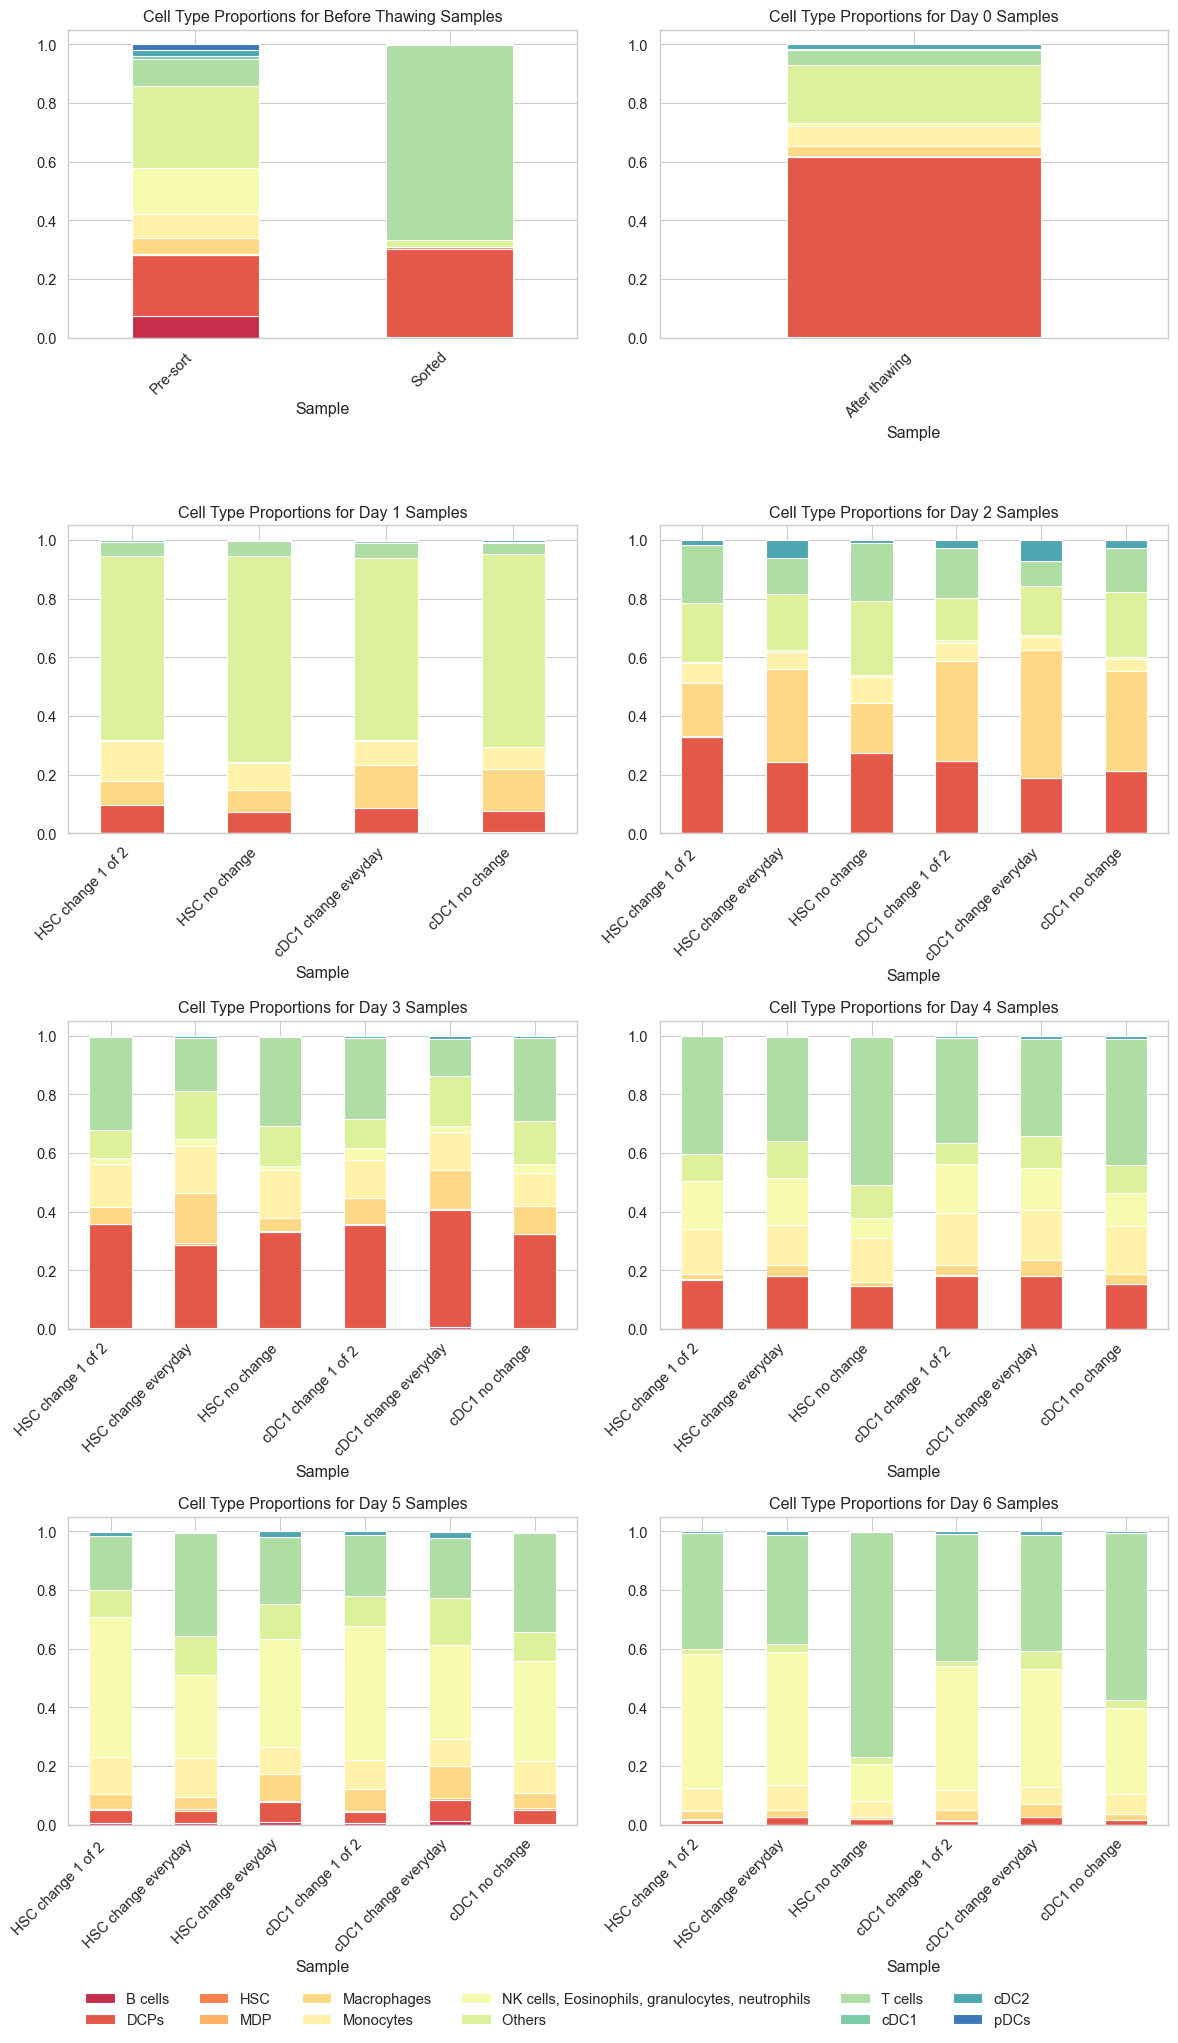

In [ ]:
# Plot a figure with the 6 days with 3 lines and 2 columns
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(12, 20))
days = list(results_by_day.keys())
for i, ax in enumerate(axes.flatten()):
    if i < len(days):
        day = days[i]
        day_data = results_by_day[day]
        day_proportions = pd.DataFrame()
        
        for sample_name, sample_data in split_by_sample(day_data).items():
            sample_proportions = sample_data.iloc[:, 2:].copy()
            sample_proportions.insert(0, "Sample", sample_name)
            day_proportions = pd.concat([day_proportions, sample_proportions], ignore_index=True)
        
        day_proportions_plot = day_proportions.melt(id_vars='Sample', var_name='Cell Type', value_name='Proportion')
        day_proportions_plot_pivot = day_proportions_plot.pivot(index='Sample', columns='Cell Type', values='Proportion')
        day_proportions_plot_pivot.plot(kind='bar', stacked=True, ax=ax)
        ax.set_title(f'Cell Type Proportions for {day} Samples')
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
        ax.legend_.remove()

plt.tight_layout()

plt.legend(
    loc='upper center',
    bbox_to_anchor=(-0.2, -0.5),
    ncol =6,
    frameon=False
)
plt.savefig('Figures/DCP_proportions_across_days.png', dpi=300, bbox_inches='tight')
plt.show()

## DCP proportions

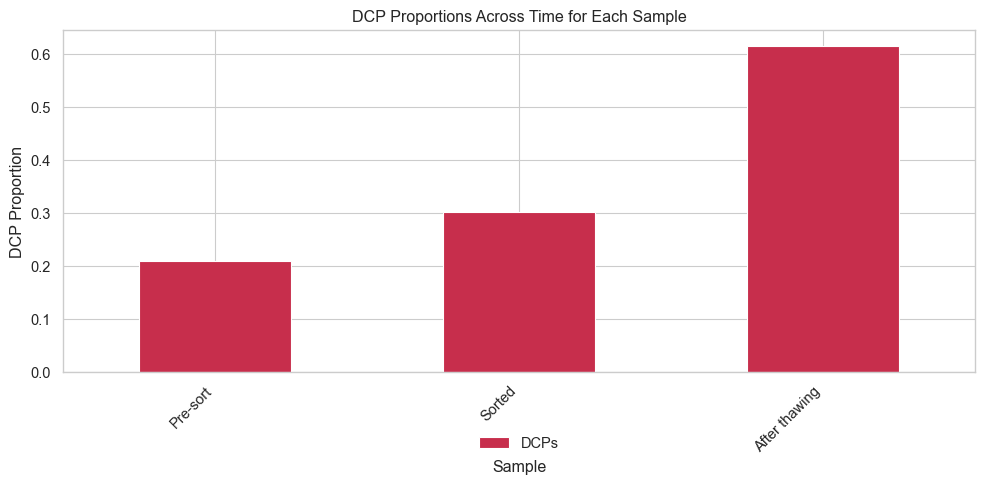

In [ ]:
# Plot bar chart of DCP proportions on first days
df_1st_days["DCPs"].plot(kind='bar', figsize=(10,5))
plt.title('DCP Proportions Across Time for Each Sample')
plt.xlabel('Sample')
plt.ylabel('DCP Proportion')
plt.xticks(rotation=45, ha='right')
plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    ncol =6,
    frameon=False
)
plt.tight_layout()
plt.show()  

<Figure size 1000x600 with 0 Axes>

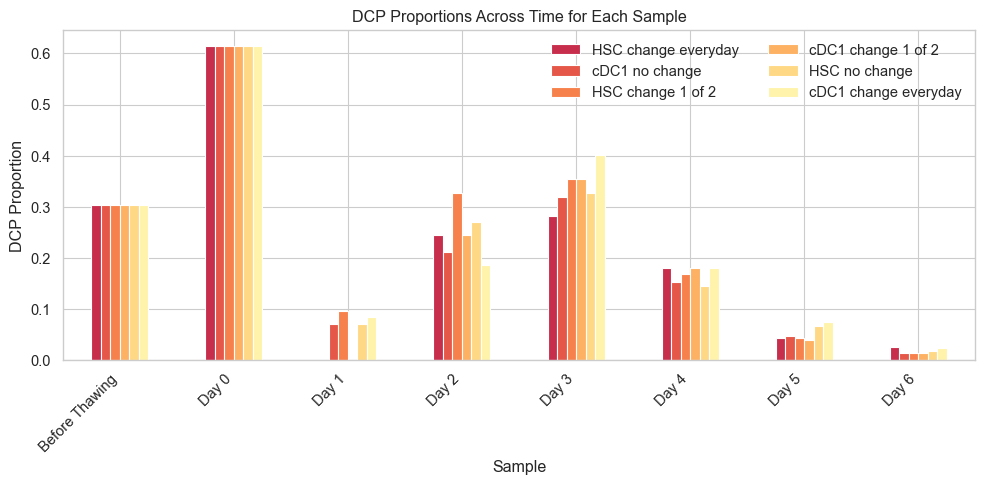

In [ ]:
# Plot bar chart of DCP proportions across time for each sample
plt.figure(figsize=(10, 6))
dcp_proportions.plot(kind='bar', figsize=(10,5))
plt.title('DCP Proportions Across Time for Each Sample')
plt.xlabel('Sample')
plt.ylabel('DCP Proportion')
plt.xticks(rotation=45, ha='right')
plt.legend(title="", frameon=False, ncol=2)
plt.tight_layout()
plt.show()  